In [3]:
import pandas as pd

df = pd.read_csv('/content/ev_vs_petrol_dataset_v3.csv')
display(df.head())

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        1200 non-null   object 
 1   region                         1200 non-null   object 
 2   year                           1200 non-null   int64  
 3   vehicle_segment                1200 non-null   object 
 4   powertrain_type                1200 non-null   object 
 5   ev_sales                       1200 non-null   int64  
 6   petrol_car_sales               1200 non-null   int64  
 7   diesel_car_sales               1200 non-null   int64  
 8   total_vehicle_sales            1200 non-null   int64  
 9   ev_market_share                1200 non-null   float64
 10  charging_stations              1200 non-null   int64  
 11  fast_chargers_share            1200 non-null   float64
 12  avg_ev_range_km                1200 non-null   i

In [5]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"New shape of the DataFrame: {df.shape}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
New shape of the DataFrame: (1200, 22)


In [7]:
highest_fuel_price_countries = df.groupby('country')['fuel_price_usd_per_liter'].max().sort_values(ascending=False)
display(highest_fuel_price_countries.head(10))

,fuel_price_usd_per_liter
country,
Norway,2.153
Netherlands,2.153
Sweden,2.097
Italy,2.053
Belgium,2.007
Germany,2.007
France,1.983
Switzerland,1.937
Portugal,1.903


In [9]:
print(f"Pearson correlation coefficient between 'fuel_price_usd_per_liter' and 'ev_market_share': {correlation}")

Pearson correlation coefficient between 'fuel_price_usd_per_liter' and 'ev_market_share': 0.553799308073848


In [10]:
avg_ev_range_by_year = df.groupby('year')['avg_ev_range_km'].mean().reset_index()
display(avg_ev_range_by_year)

,year,avg_ev_range_km
0,2010,120.28
1,2011,128.20
2,2012,139.16
3,2013,143.12
4,2014,153.44
5,2015,168.60
6,2016,188.04
7,2017,217.48
8,2018,258.56
9,2019,295.08


/tmp/ipython-input-2733221799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='avg_ev_range_km', data=avg_ev_range_by_year, palette='viridis')


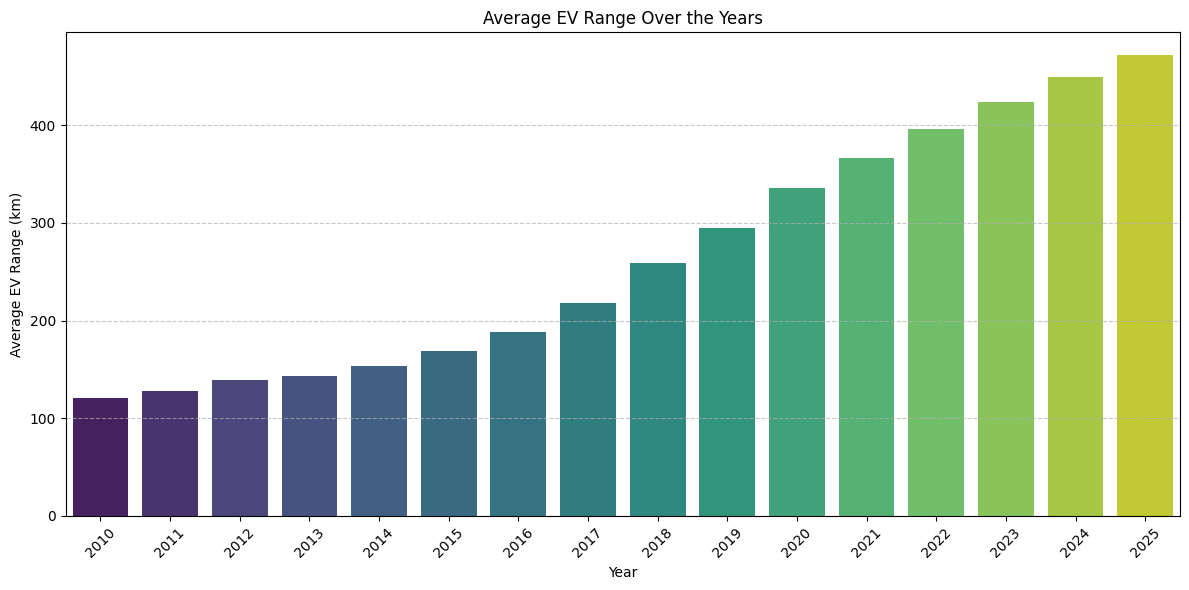

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='year', y='avg_ev_range_km', data=avg_ev_range_by_year, palette='viridis')
plt.title('Average EV Range Over the Years')
plt.xlabel('Year')
plt.ylabel('Average EV Range (km)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()